# 1. CONFIGURACIÓN DE HARDWARE (RTX 2060)

In [ ]:
import tensorflow as tf
from tensorflow.keras import mixed_precision
import os

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU Configurada: {len(gpus)} dispositivo(s)")
    except RuntimeError as e:
        print(e)

mixed_precision.set_global_policy('mixed_float16')
print(f"✅ Política de precisión: {mixed_precision.global_policy().name}")

✅ GPU Configurada: 1 dispositivo(s)
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 2060, compute capability 7.5
✅ Política de precisión: mixed_float16


# 2. CARGA DE DATOS (PIPELINE OPTIMIZADO)

In [3]:
import pathlib
import matplotlib.pyplot as plt
import numpy as np

# Windows
data_dir = pathlib.Path(r'C:\Users\angel\MyCode\ITM-2025-IA\projects\20251015_cnn\data')

batch_size = 64
img_height = 128
img_width = 128
seed = 123

print("\n--- Cargando Dataset de Entrenamiento ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="training",
  seed=seed,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='categorical'
)

print("\n--- Cargando Dataset de Validación ---")
val_ds = tf.keras.utils.image_dataset_from_directory(
  data_dir,
  validation_split=0.2,
  subset="validation",
  seed=seed,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  label_mode='categorical'
)

class_names = train_ds.class_names
n_classes = len(class_names)
print(f"\nClases encontradas: {class_names}")


--- Cargando Dataset de Entrenamiento ---
Found 98348 files belonging to 5 classes.
Using 78679 files for training.

--- Cargando Dataset de Validación ---
Found 98348 files belonging to 5 classes.
Using 19669 files for validation.

Clases encontradas: ['catarina', 'gato', 'hormiga', 'perro', 'tortuga']


# 3. OPTIMIZACIÓN DEL FLUJO DE DATOS (CPU -> GPU)

<Figure size 1000x500 with 0 Axes>

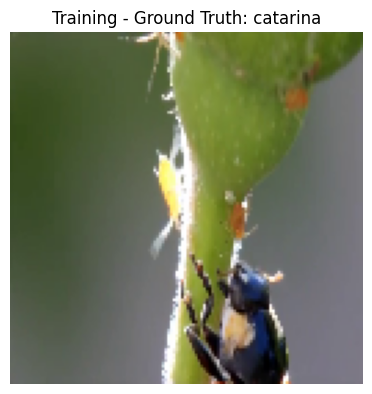

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

normalization_layer = tf.keras.layers.Rescaling(1./255)

def preprocess(image, label):
    return normalization_layer(image), label

train_ds = train_ds.map(preprocess).cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.map(preprocess).cache().prefetch(buffer_size=AUTOTUNE)

plt.figure(figsize=(10, 5))

for images, labels in train_ds.take(1):
    image_array = images[0].numpy()

    image_to_plot = (image_array * 255).astype(np.uint8)

    if image_to_plot.shape[-1] == 1:
        image_to_plot = np.squeeze(image_to_plot, axis=-1) # Change (H, W, 1) to (H, W)

    plt.subplot(1, 2, 1)
    plt.imshow(image_to_plot, cmap='gray')
    plt.title(f"Training - Ground Truth: {class_names[np.argmax(labels[0])]}")
    plt.axis('off')

# ... (do the same for val_ds)
plt.show()

# 4. DEFINICIÓN DEL MODELO (TU ARQUITECTURA)

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, LeakyReLU, BatchNormalization, GlobalAveragePooling2D

model = Sequential([
    tf.keras.layers.InputLayer(input_shape=(img_height, img_width, 3)),

    Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2, 2), padding='same'),

    Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.3),

    Conv2D(128, (3, 3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.4),

    GlobalAveragePooling2D(),

    Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.L2(0.001)),
    Dropout(0.5),

    Dense(n_classes, activation='softmax', dtype='float32')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 128, 128, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 64, 64, 64)       256       
 hNormalization)                                                 
                                                        

# 5. COMPILACIÓN Y ENTRENAMIENTO

In [6]:
INIT_LR = 1e-3
epochs = 20

model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.SGD(learning_rate=INIT_LR, momentum=0.9),
    metrics=['accuracy'],
)

print(f"\n--- Iniciando Entrenamiento por {epochs} épocas ---")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1
)

model.save("gpu_animales_e100_000.h5")
print("Modelo guardado.")


--- Iniciando Entrenamiento por 20 épocas ---
Epoch 1/20
1230/1230 [==============================] - 110s 67ms/step - loss: 0.8171 - accuracy: 0.7864 - val_loss: 2.2642 - val_accuracy: 0.3833
Epoch 2/20
1230/1230 [==============================] - 54s 44ms/step - loss: 0.5812 - accuracy: 0.8785 - val_loss: 3.2243 - val_accuracy: 0.4857
Epoch 3/20
1230/1230 [==============================] - 52s 42ms/step - loss: 0.4909 - accuracy: 0.9074 - val_loss: 2.7310 - val_accuracy: 0.5372
Epoch 4/20
1230/1230 [==============================] - 56s 45ms/step - loss: 0.4382 - accuracy: 0.9230 - val_loss: 1.3665 - val_accuracy: 0.7401
Epoch 5/20
1230/1230 [==============================] - 59s 48ms/step - loss: 0.4014 - accuracy: 0.9352 - val_loss: 1.1237 - val_accuracy: 0.7366
Epoch 6/20
1230/1230 [==============================] - 58s 47ms/step - loss: 0.3640 - accuracy: 0.9426 - val_loss: 0.4045 - val_accuracy: 0.9329
Epoch 7/20
1230/1230 [==============================] - 59s 48ms/step - loss

# 6. VISUALIZACIÓN DE RESULTADOS

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

# 6. TESTING

Cargando modelo desde /home/angeld/MyCode/ITM-2025-IA/projects/20251015_cnn/models/gpu_animales_e20_001.h5...
📂 Cargando imagen local...
1/1 [==============================] - 0s 153ms/step


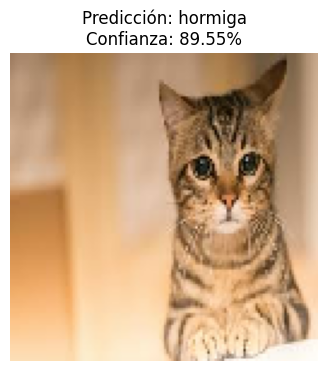

 Resultado: hormiga (89.55%)
 Probabilidades completas: [6.5713003e-03 3.5200952e-04 8.9547098e-01 9.7342066e-02 2.6365073e-04]


In [34]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
import requests
import pathlib
from io import BytesIO
from PIL import Image


# MODEL_PATH = pathlib.Path(r'./models/models/gpu_animales_e20_001.h5')
MODEL_PATH = pathlib.Path(r'/home/angeld/MyCode/ITM-2025-IA/projects/20251015_cnn/models/gpu_animales_e20_001.h5')
IMG_SIZE = (128, 128)
class_names = ['catarina', 'gato', 'hormiga', 'perro', 'tortuga']

print(f"Cargando modelo desde {MODEL_PATH}...")
model = tf.keras.models.load_model(MODEL_PATH)

def cargar_imagen(path_or_url):
    """
    Carga una imagen desde una ruta local o una URL,
    la redimensiona y asegura que esté en formato RGB.
    """
    path_str = str(path_or_url)

    if path_str.startswith(('http://', 'https://')):
        print(f"🌐 Descargando imagen de URL...")
        response = requests.get(path_str)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content))
        img = img.resize(IMG_SIZE)
    else:
        print(f"📂 Cargando imagen local...")
        img = image.load_img(path_or_url, target_size=IMG_SIZE)
    if img.mode != 'RGB':
        img = img.convert('RGB')
    return img

def predecir_imagen(img_path):
    try:
        img = cargar_imagen(img_path)

        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = img_array / 255.0

        predictions = model.predict(img_array)
        score = predictions[0]

        predicted_class = class_names[np.argmax(score)]
        confidence = 100 * np.max(score)

        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Predicción: {predicted_class}\nConfianza: {confidence:.2f}%")
        plt.show()

        print(f" Resultado: {predicted_class} ({confidence:.2f}%)")
        print(f" Probabilidades completas: {score}")

    except Exception as e:
        print(f"❌ Error al procesar la imagen: {e}")


local = pathlib.Path(r'/home/angeld/MyCode/ITM-2025-IA/projects/20251015_cnn/image.png')

internet = ""
predecir_imagen(local)